In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hybrid_forecast_results.csv")

df.head()

,Date,Actual,Prophet_Prediction,LSTM_Prediction,Hybrid_Prediction
0,2011-11-06,23288,8009.596240,19770.945,13890.270776
1,2011-11-07,16443,13253.978288,19817.879,16535.928597
2,2011-11-08,21658,22356.290964,19651.768,21004.029271
3,2011-11-09,37016,22087.758675,19405.674,20746.716252
4,2011-11-10,38098,21052.411106,19121.732,20087.071764


In [3]:
df.info()

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                30 non-null     object 
 1   Actual              30 non-null     int64  
 2   Prophet_Prediction  30 non-null     float64
 3   LSTM_Prediction     30 non-null     float64
 4   Hybrid_Prediction   30 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.3+ KB
Index(['Date', 'Actual', 'Prophet_Prediction', 'LSTM_Prediction',
       'Hybrid_Prediction'],
      dtype='object')


In [4]:
df["Safety_Stock"] = df["Hybrid_Prediction"] * 0.20

df.head()

,Date,Actual,Prophet_Prediction,LSTM_Prediction,Hybrid_Prediction,Safety_Stock
0,2011-11-06,23288,8009.596240,19770.945,13890.270776,2778.054155
1,2011-11-07,16443,13253.978288,19817.879,16535.928597,3307.185719
2,2011-11-08,21658,22356.290964,19651.768,21004.029271,4200.805854
3,2011-11-09,37016,22087.758675,19405.674,20746.716252,4149.343250
4,2011-11-10,38098,21052.411106,19121.732,20087.071764,4017.414353


In [5]:
df["Recommended_Inventory"] = (
    df["Hybrid_Prediction"] + df["Safety_Stock"]
)

df["Safety_Stock"] = df["Safety_Stock"].round(0)
df["Recommended_Inventory"] = df["Recommended_Inventory"].round(0)

df.head()

,Date,Actual,Prophet_Prediction,LSTM_Prediction,Hybrid_Prediction,Safety_Stock,Recommended_Inventory
0,2011-11-06,23288,8009.596240,19770.945,13890.270776,2778.0,16668.0
1,2011-11-07,16443,13253.978288,19817.879,16535.928597,3307.0,19843.0
2,2011-11-08,21658,22356.290964,19651.768,21004.029271,4201.0,25205.0
3,2011-11-09,37016,22087.758675,19405.674,20746.716252,4149.0,24896.0
4,2011-11-10,38098,21052.411106,19121.732,20087.071764,4017.0,24104.0


In [6]:
def inventory_status(stock):

    if stock < 50:
        return "Low Stock"

    elif stock < 200:
        return "Medium Stock"

    else:
        return "High Stock"

df["Inventory_Status"] = df["Recommended_Inventory"].apply(inventory_status)

df.head()

,Date,Actual,Prophet_Prediction,LSTM_Prediction,Hybrid_Prediction,Safety_Stock,Recommended_Inventory,Inventory_Status
0,2011-11-06,23288,8009.596240,19770.945,13890.270776,2778.0,16668.0,High Stock
1,2011-11-07,16443,13253.978288,19817.879,16535.928597,3307.0,19843.0,High Stock
2,2011-11-08,21658,22356.290964,19651.768,21004.029271,4201.0,25205.0,High Stock
3,2011-11-09,37016,22087.758675,19405.674,20746.716252,4149.0,24896.0,High Stock
4,2011-11-10,38098,21052.411106,19121.732,20087.071764,4017.0,24104.0,High Stock


In [7]:
print("Total Records :", len(df))

print("\nAverage Forecast Demand :", round(df["Hybrid_Prediction"].mean(),2))

print("\nAverage Recommended Inventory :", round(df["Recommended_Inventory"].mean(),2))

print("\nInventory Status Count")

print(df["Inventory_Status"].value_counts())

Total Records : 30

Average Forecast Demand : 17845.97

Average Recommended Inventory : 21415.1

Inventory Status Count
Inventory_Status
High Stock    30
Name: count, dtype: int64


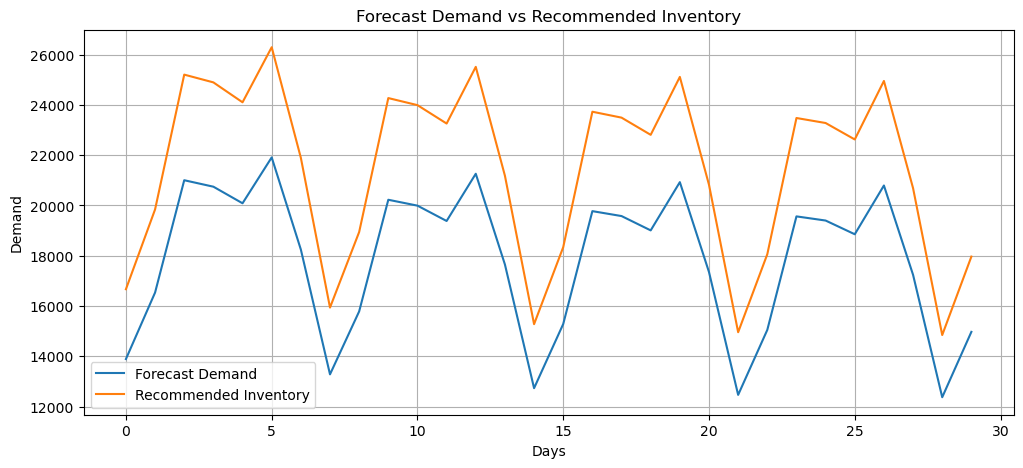

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df["Hybrid_Prediction"], label="Forecast Demand")
plt.plot(df["Recommended_Inventory"], label="Recommended Inventory")

plt.title("Forecast Demand vs Recommended Inventory")

plt.xlabel("Days")
plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

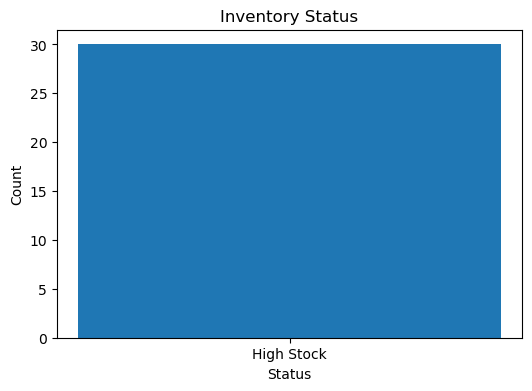

In [9]:
status = df["Inventory_Status"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(status.index, status.values)

plt.title("Inventory Status")

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()

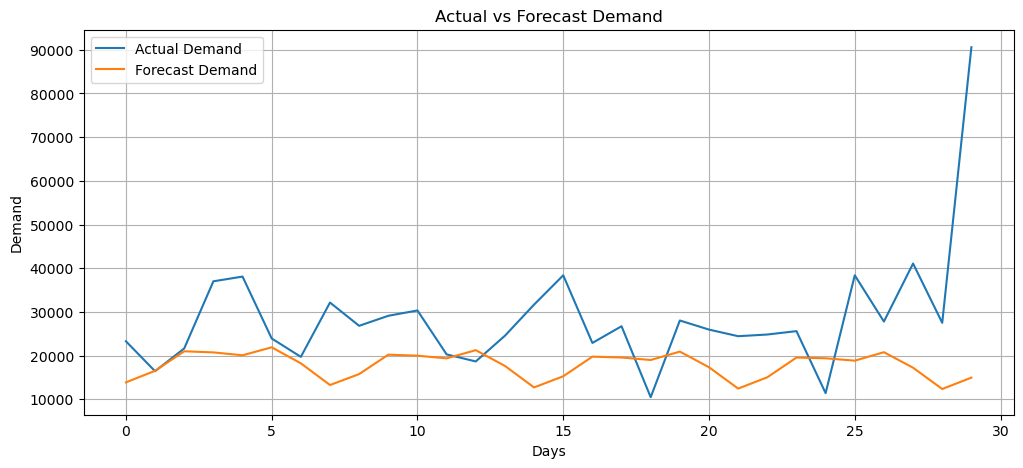

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df["Actual"], label="Actual Demand")
plt.plot(df["Hybrid_Prediction"], label="Forecast Demand")

plt.title("Actual vs Forecast Demand")

plt.xlabel("Days")
plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

In [11]:
df.to_csv("inventory_optimization_results.csv", index=False)

print("Inventory Optimization Completed Successfully!")
print("File Saved as inventory_optimization_results.csv")

Inventory Optimization Completed Successfully!
File Saved as inventory_optimization_results.csv
